# MIR: treating Xarray data as unstructured in regridding

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

import earthkit.geo as ekg

## Load the data

We fetch a river discharge field from the EFAS (European Flood Awareness System) reanalysis in NetCDF and convert it to Xarray with earthkit-data. The data is defined on a Lambert Azimuthal Equal Area projection, described by 1D ``x``/``y`` coordinates plus 2D ``latitude``/``longitude`` coordinates.

In [2]:
ds = ekd.from_source("sample", "efas.nc").to_xarray()
ds

efas.nc:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

<xarray.Dataset> Size: 24MB
Dimensions:                       (y: 950, x: 1000)
Coordinates:
  * y                             (y) float64 8kB 5.498e+06 ... 7.525e+05
  * x                             (x) float64 8kB 2.502e+06 ... 7.498e+06
    latitude                      (y, x) float64 8MB ...
    longitude                     (y, x) float64 8MB ...
    time                          datetime64[ns] 8B ...
    step                          float64 8B ...
    surface                       float64 8B ...
    valid_time                    datetime64[ns] 8B ...
Data variables:
    dis06                         (y, x) float32 4MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    land_binary_mask              (y, x) int8 950kB ...
    upArea                        (y, x) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2022-11-10T10:57 GRIB to CDM+CF via cfgrib-0.9.9...

In [3]:
ds.earthkit.grid_spec  # returns None

## Regridding

In [4]:
# the target grid is a 0.1x0.1 degree regular latitude-longitude grid over the EFAS domain
out_grid = {"grid": [0.1, 0.1], "area": [75, -30, 30, 40]}

# perform interpolation
r = ekg.regrid(ds.dis06, out_grid=out_grid, interpolation="nn")
r

<xarray.DataArray 'dis06' (latitude: 451, longitude: 701)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(451, 701), dtype=float32)
Coordinates:
  * latitude    (latitude) float64 4kB 75.0 74.9 74.8 74.7 ... 30.2 30.1 30.0
  * longitude   (longitude) float64 6kB -30.0 -29.9 -29.8 ... 39.8 39.9 40.0
    time        datetime64[ns] 8B ...
    step        float64 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/19)
    GRIB_paramId:                    240023
    GRIB_dataType:                   sfo
    GRIB_numberOfPoints:             950000
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   avg
    ...                              ...
    GRIB_shortName:                  dis06
    GRIB_units:                      m**3 s**-1
    long_name:                       Mean discharge in the last 6 hours
    units:                           m**3 s**-1
    standard_name:                   unknown
    grid_mapping:                    lambert_azimuthal_equal_area

Since the output grid is a regular latitude-longitude mesh, the resulting ``DataArray`` has separate ``latitude``/``longitude`` dimensions, each with its own 1D coordinate array. However, since the input dataset did not carry an earthkit-data grid spec attribute to begin with, the output does not get one either.

In [5]:
r.earthkit.grid_spec  # returns None

We check the result visually by plotting it.

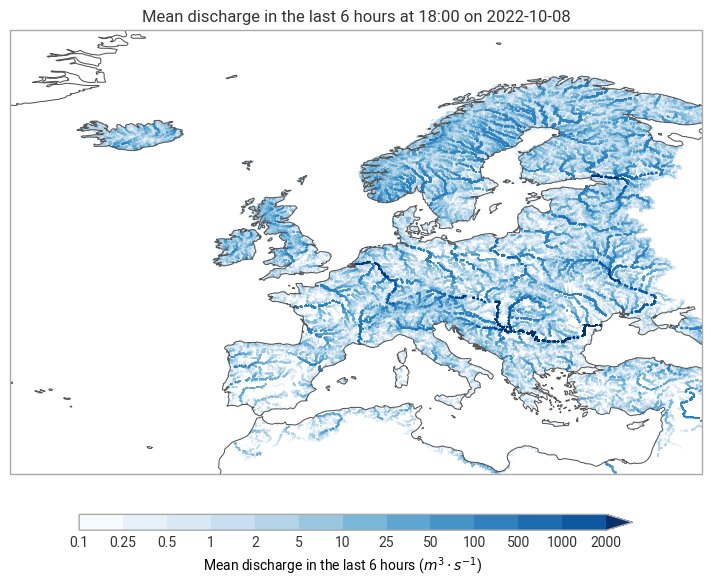

In [6]:
ekp.quickplot(r)